<a href="https://colab.research.google.com/github/LadyRhanes/concrete/blob/main/concrete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
%pip install ydata-profiling
from ydata_profiling import ProfileReport
from matplotlib import cm
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.feature_selection import SelectKBest,f_classif,f_regression
from sklearn.svm import SVC
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPRegressor
from sklearn.neighbors import KNeighborsRegressor
import statsmodels.api as sm
from sklearn.metrics import mean_squared_error, r2_score

In [5]:
dataset='/content/ds.txt'
data=pd.read_csv(dataset)
data.head()



,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30


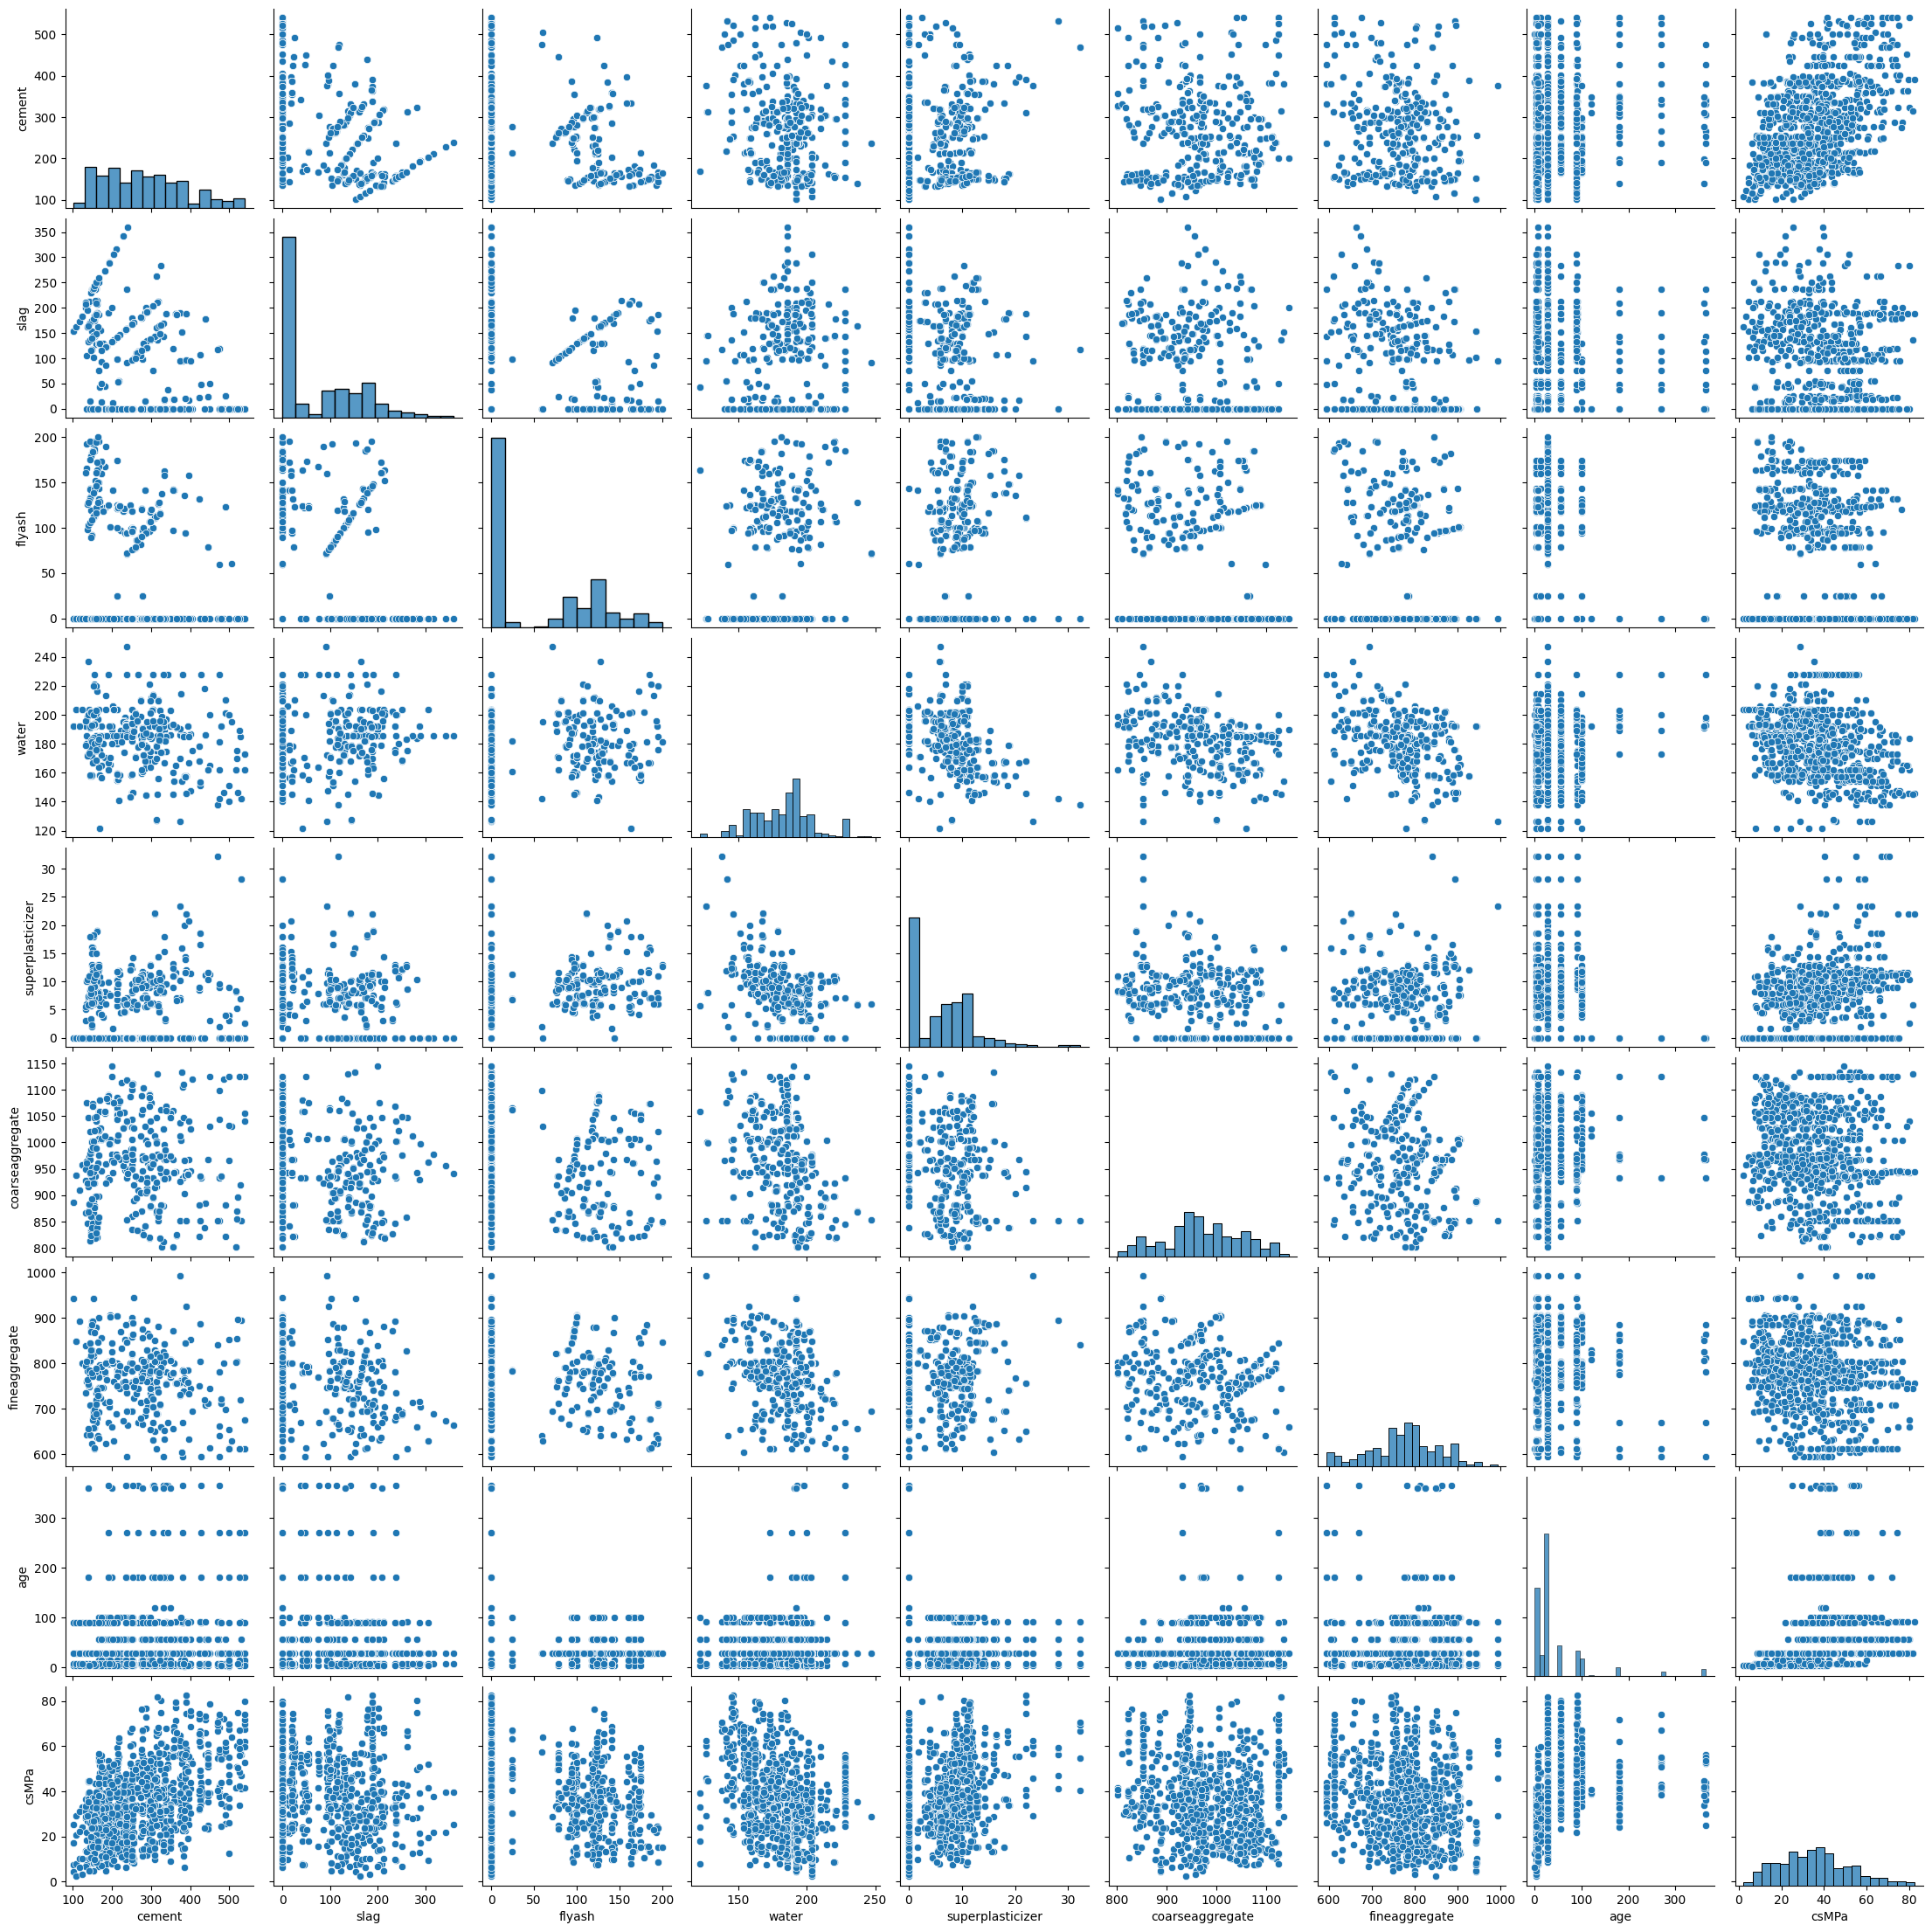

In [6]:
sns.pairplot(data)

In [7]:
data['strength']=np.where(data['csMPa']>=44 ,'high','low')
data.head()


,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,high
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,high
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,low
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,low
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,high


In [8]:
data.describe()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa
count,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000,1030.000000
mean,281.167864,73.895825,54.188350,181.567282,6.204660,972.918932,773.580485,45.662136,35.817961
std,104.506364,86.279342,63.997004,21.354219,5.973841,77.753954,80.175980,63.169912,16.705742
min,102.000000,0.000000,0.000000,121.800000,0.000000,801.000000,594.000000,1.000000,2.330000
25%,192.375000,0.000000,0.000000,164.900000,0.000000,932.000000,730.950000,7.000000,23.710000
50%,272.900000,22.000000,0.000000,185.000000,6.400000,968.000000,779.500000,28.000000,34.445000
75%,350.000000,142.950000,118.300000,192.000000,10.200000,1029.400000,824.000000,56.000000,46.135000
max,540.000000,359.400000,200.100000,247.000000,32.200000,1145.000000,992.600000,365.000000,82.600000


In [9]:
profile=ProfileReport(data,explorative=True ,minimal= True)
profile.to_notebook_iframe()

Summarize dataset:   0%|          | 0/5 [00:00<?, ?it/s]


100%|██████████| 10/10 [00:00<00:00, 90.47it/s]


Generate report structure:   0%|          | 0/1 [00:00<?, ?it/s]

Render HTML:   0%|          | 0/1 [00:00<?, ?it/s]

In [10]:
data['strength'].value_counts()

,count
strength,
low,736
high,294


<BarContainer object of 2 artists>

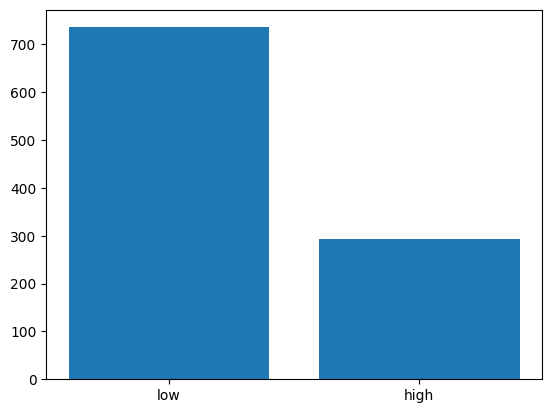

In [11]:
plt.bar(x=['low','high'],height=data['strength'].value_counts())

In [12]:
data.strength=[1 if x=='high' else 0 for x in data.strength ]
data.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,strength
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.99,1
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.89,1
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,1


,0
cement,"Axes(0.125,0.53;0.133621x0.35)"
slag,"Axes(0.285345,0.53;0.133621x0.35)"
flyash,"Axes(0.44569,0.53;0.133621x0.35)"
water,"Axes(0.606034,0.53;0.133621x0.35)"
superplasticizer,"Axes(0.766379,0.53;0.133621x0.35)"
coarseaggregate,"Axes(0.125,0.11;0.133621x0.35)"
fineaggregate,"Axes(0.285345,0.11;0.133621x0.35)"
age,"Axes(0.44569,0.11;0.133621x0.35)"
csMPa,"Axes(0.606034,0.11;0.133621x0.35)"
strength,"Axes(0.766379,0.11;0.133621x0.35)"


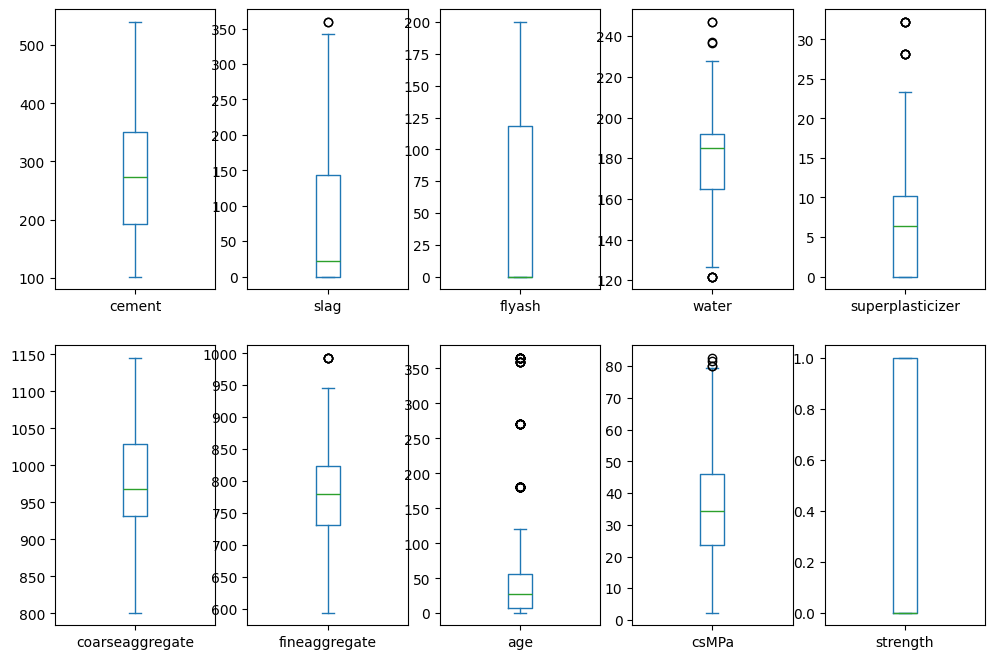

In [13]:
data.plot(kind='box',subplots=True,layout=(2,5),figsize=(12,8))

In [14]:
outliers=data.loc[(data['fineaggregate'] >950) | (data['slag']>350)| (data['water']>235) | (data['superplasticizer']>25) | (data['csMPa']>80)|(data['age']>150)]
outliers

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,strength
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.27,0
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.05,0
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.30,1
6,380.0,95.0,0.0,228.0,0.0,932.0,594.0,365,43.70,0
12,427.5,47.5,0.0,228.0,0.0,932.0,594.0,270,43.01,0
...,...,...,...,...,...,...,...,...,...,...
823,322.0,0.0,0.0,203.0,0.0,974.0,800.0,180,29.59,0
862,140.0,164.0,128.0,237.0,6.0,869.0,656.0,28,35.23,0
873,237.0,92.0,71.0,247.0,6.0,853.0,695.0,28,28.63,0
936,236.9,91.7,71.5,246.9,6.0,852.9,695.4,28,28.63,0


In [15]:
data=data.loc[(data['fineaggregate'] <950) & (data['slag']<350)&(data['water']<235) & (data['superplasticizer']<25) &(data['csMPa']<80)&(data['age']<150)]
len(data)

947

,0
cement,"Axes(0.125,0.53;0.133621x0.35)"
slag,"Axes(0.285345,0.53;0.133621x0.35)"
flyash,"Axes(0.44569,0.53;0.133621x0.35)"
water,"Axes(0.606034,0.53;0.133621x0.35)"
superplasticizer,"Axes(0.766379,0.53;0.133621x0.35)"
coarseaggregate,"Axes(0.125,0.11;0.133621x0.35)"
fineaggregate,"Axes(0.285345,0.11;0.133621x0.35)"
age,"Axes(0.44569,0.11;0.133621x0.35)"
csMPa,"Axes(0.606034,0.11;0.133621x0.35)"
strength,"Axes(0.766379,0.11;0.133621x0.35)"


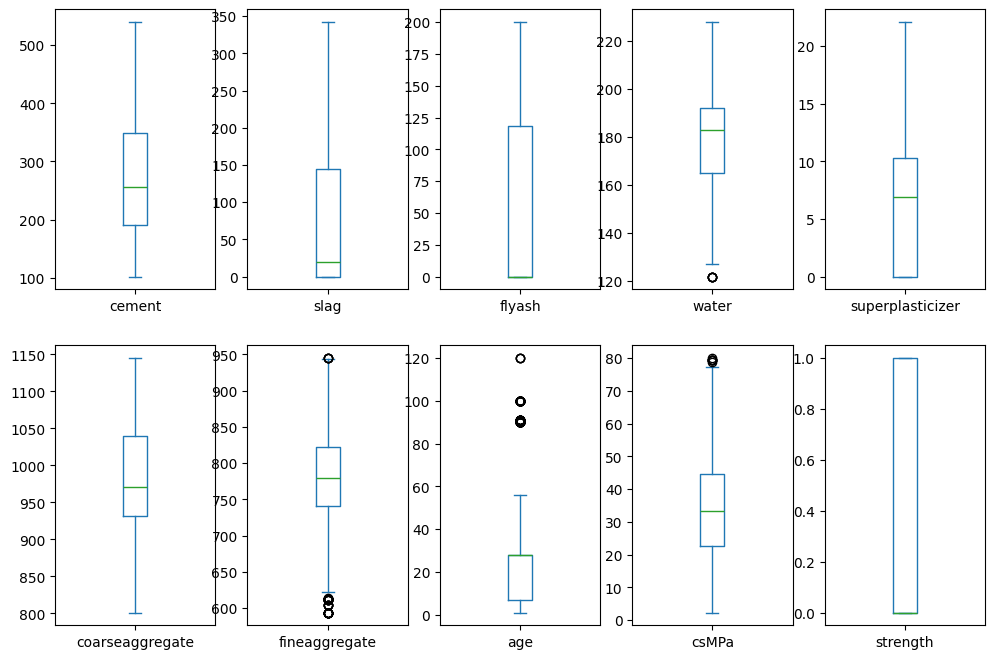

In [16]:
data.plot(kind='box',subplots=True,layout=(2,5),figsize=(12,8))

<Axes: >

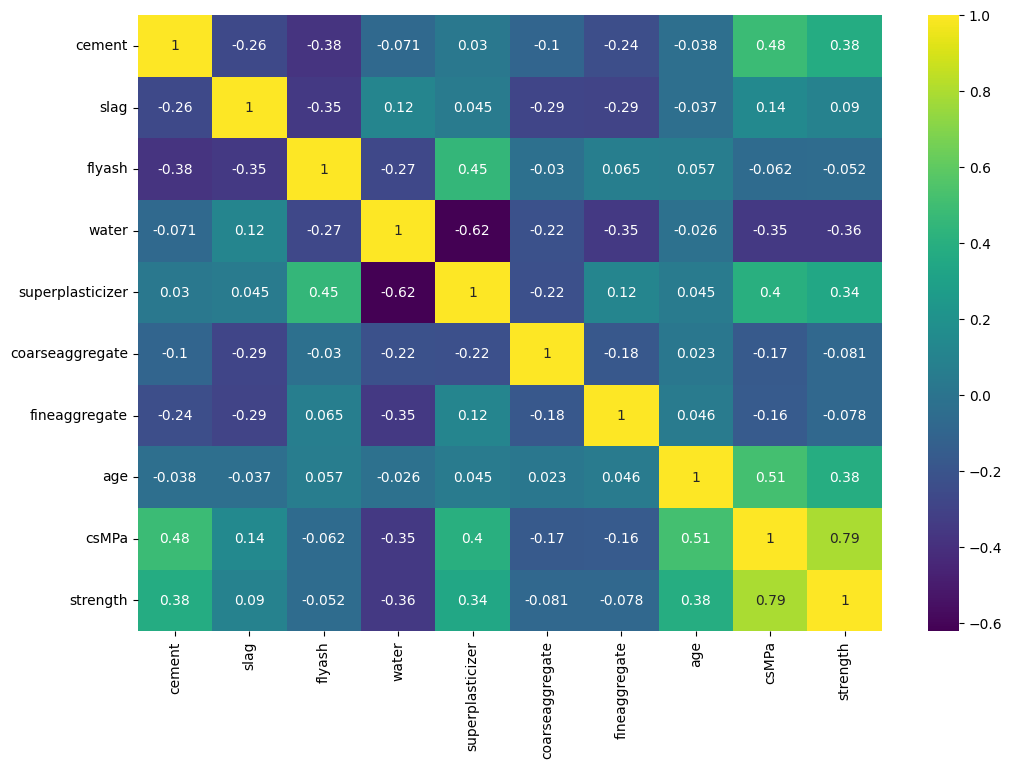

In [17]:
plt.figure(figsize=(12,8))
ax=plt.gca()
sns.heatmap(data.corr(),annot=True,ax=ax,cmap='viridis')



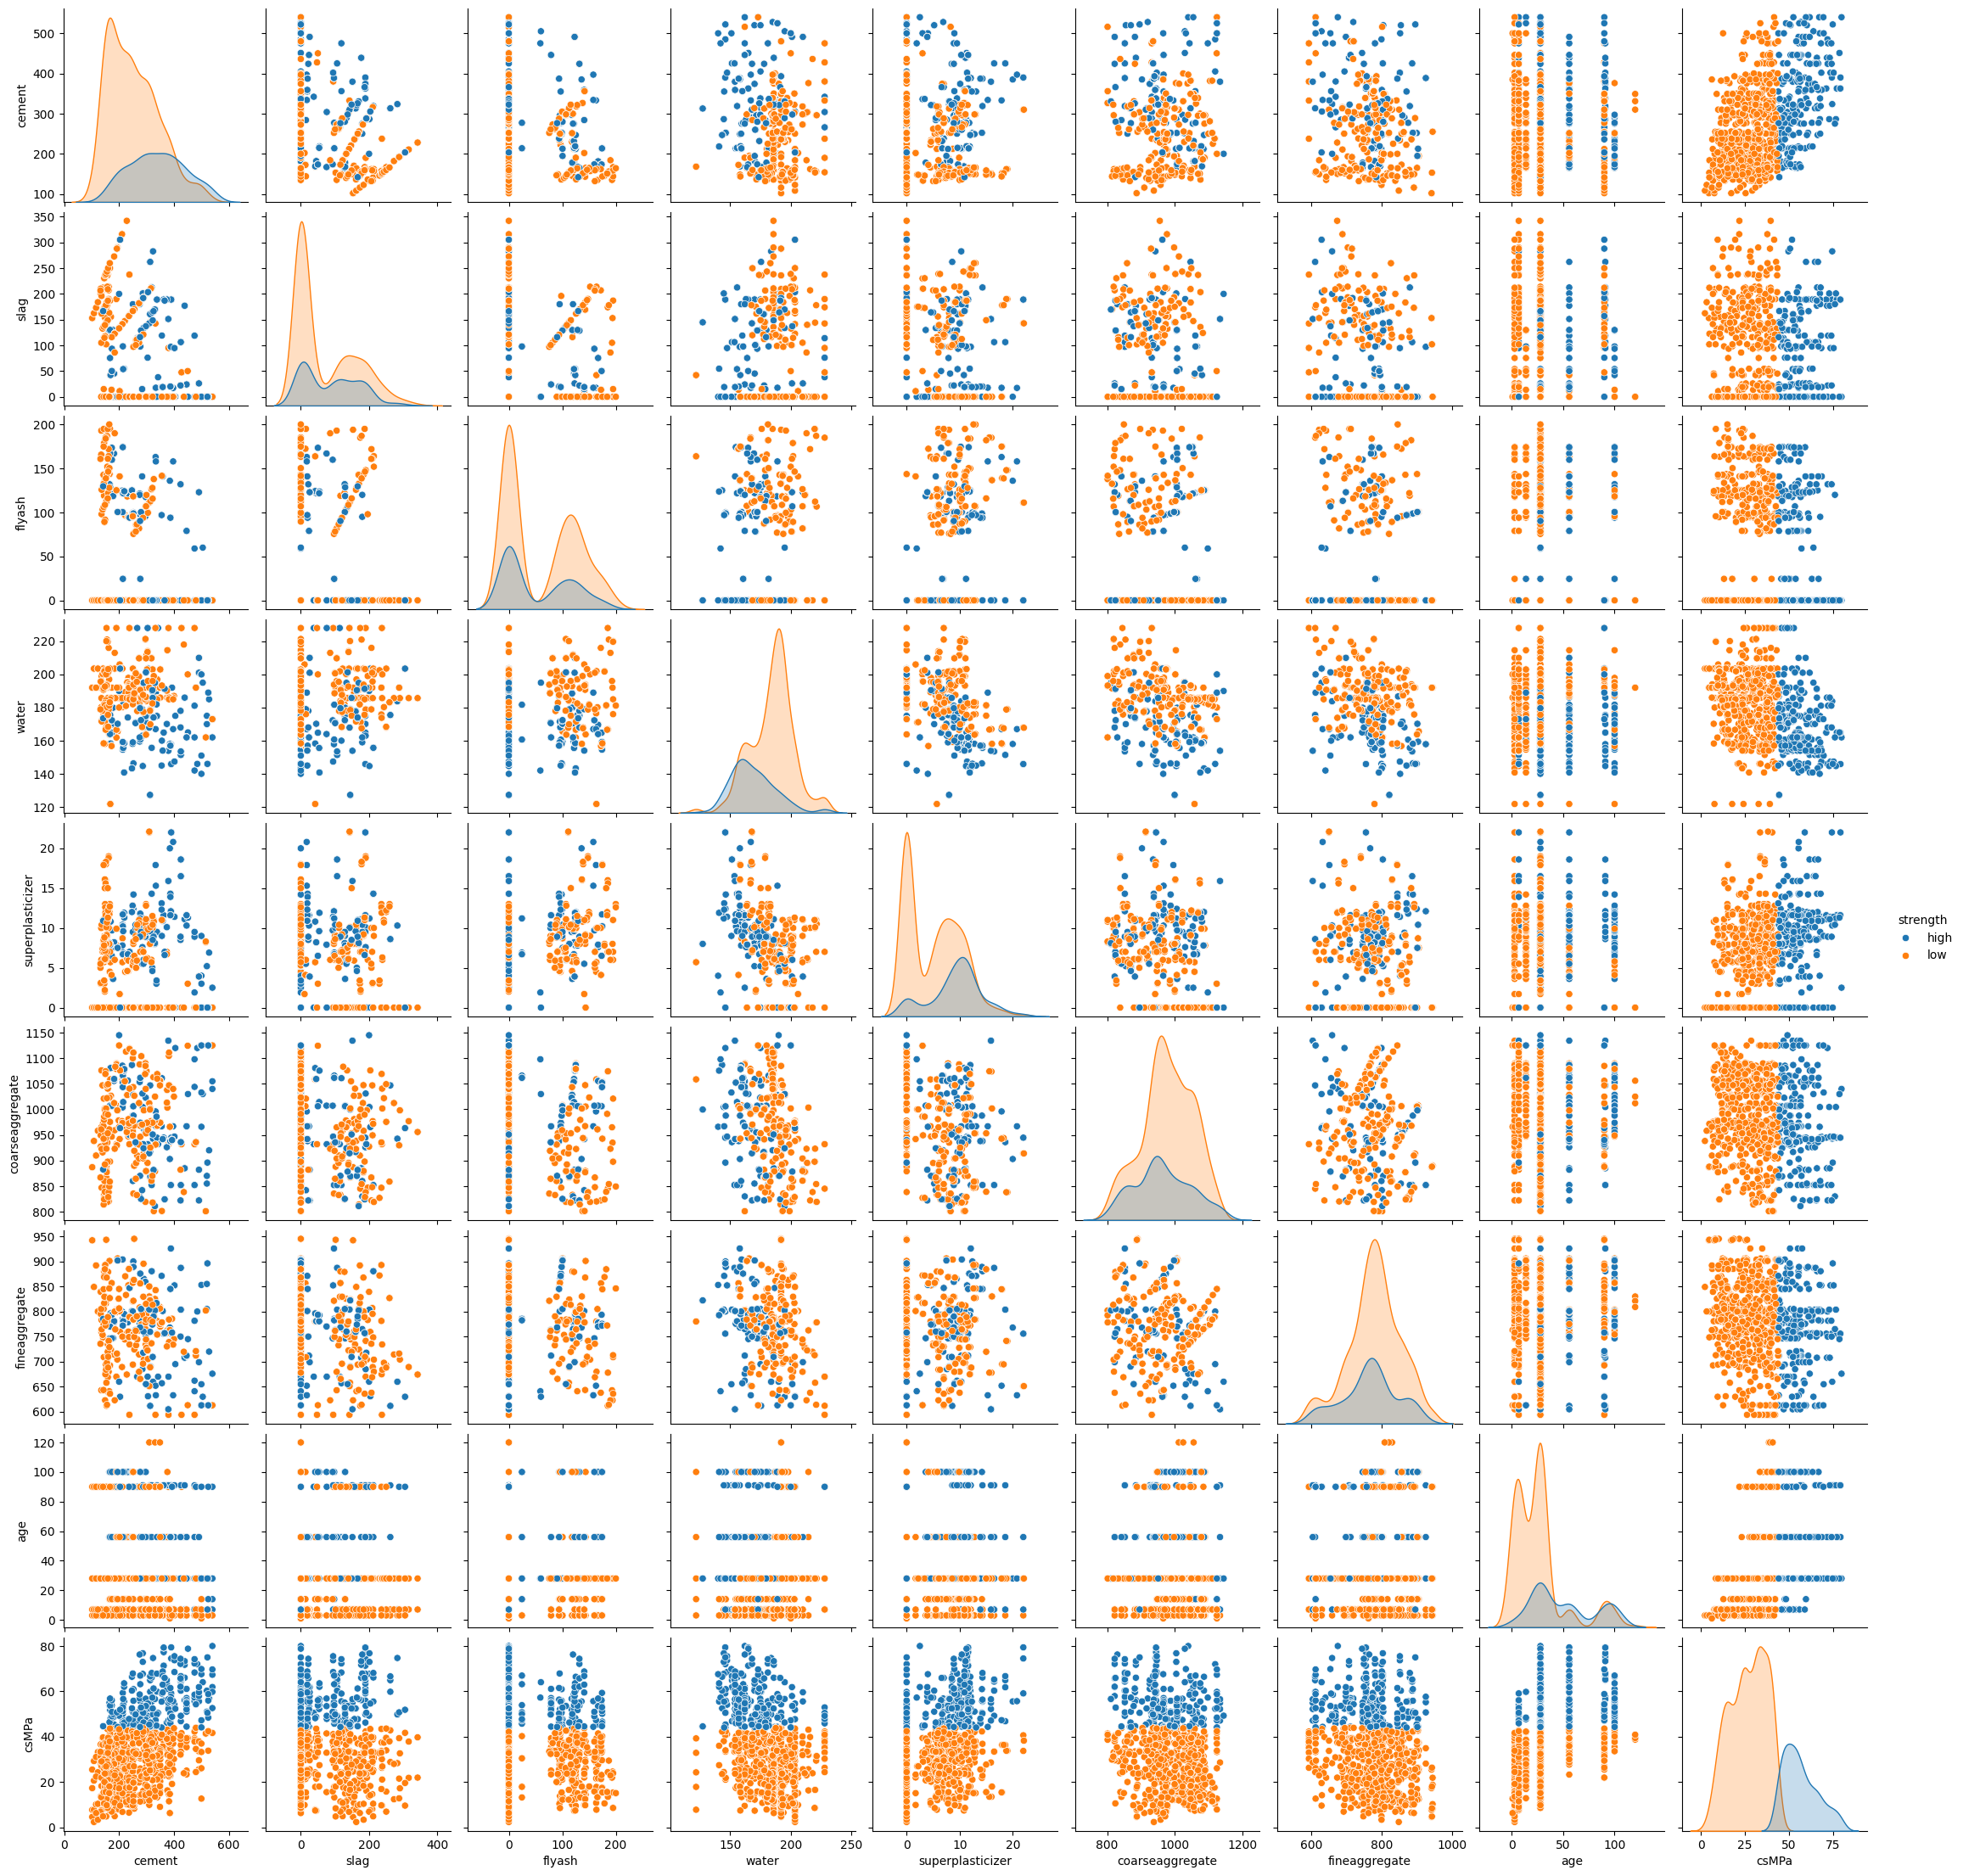

In [18]:
dpair=data.copy()
dpair['strength']=np.where(dpair['strength']==1 ,'high','low')
sns.pairplot(dpair,hue='strength')


In [19]:
y_name='strength'
X_name=list(data.columns)
X_name.remove(y_name)
X_name.remove('csMPa')
print(X_name)
X=data[X_name]
y=data[y_name]

['cement', 'slag', 'flyash', 'water', 'superplasticizer', 'coarseaggregate', 'fineaggregate', 'age']


In [20]:
s=StandardScaler()
Xs=s.fit_transform(X)
Xs=pd.DataFrame(Xs,columns=X.columns)
Xs.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age
0,2.588977,-0.854972,-0.905696,-0.954036,-0.702758,0.833224,-1.341873,-0.154454
1,2.588977,-0.854972,-0.905696,-0.954036,-0.702758,1.026458,-1.341873,-0.154454
2,-0.092737,0.469036,-0.905696,2.489034,-1.172447,-0.558061,-1.422013,2.015588
3,1.023012,0.248368,-0.905696,2.489034,-1.172447,-0.558061,-2.437123,-0.154454
4,-0.092737,0.469036,-0.905696,2.489034,-1.172447,-0.558061,-1.422013,-0.154454


In [21]:
X_train,X_test,y_train,y_test=train_test_split(Xs,y,test_size=0.2,random_state=101,shuffle=True)


<Axes: xlabel='Features'>

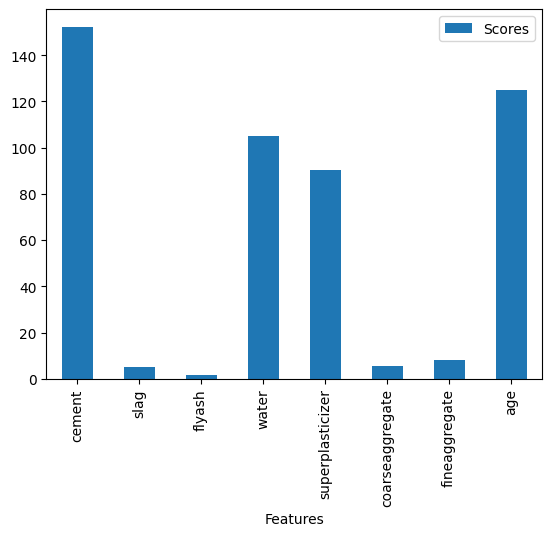

In [22]:
skb=SelectKBest(f_classif,k='all')
fit=skb.fit(X_train,y_train)
scores=pd.DataFrame({'Features':X_train.columns,'Scores':fit.scores_})
scores=scores.set_index('Features',drop=True)
scores.plot(kind='bar')


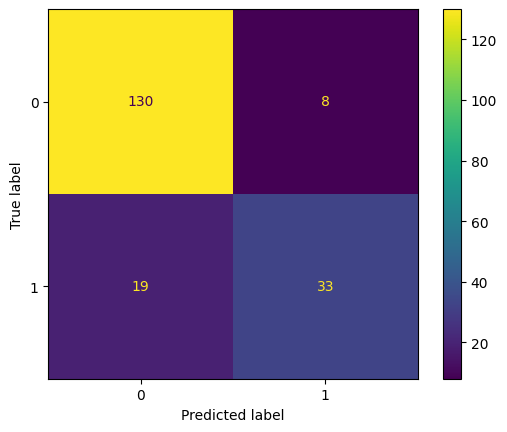

In [23]:
from sklearn.metrics import ConfusionMatrixDisplay

lr = LogisticRegression()
lr.fit(X_train, y_train)

ConfusionMatrixDisplay.from_estimator(lr, X_test, y_test)
plt.show()

In [24]:
nb=GaussianNB()
lr=LogisticRegression()
sgd=SGDClassifier()
mlp=MLPClassifier()
knn=KNeighborsClassifier()
dt=DecisionTreeClassifier()
rf=RandomForestClassifier()
sv=SVC()
nn=MLPClassifier(max_iter=2000)
clsfrs=[[nb,'Naive Bayes'],[lr,'Logistic Regression'],[sgd,'Stochastic Gradient Descent'],[mlp,'Multilayer Perceptron'],[knn,'K-Nearest Neighbors'],[dt,'Decision Tree'],[rf,'Random Forest'],[sv,'Support Vector Machine'],[nn,'Neural Network']]
for clf,nname in clsfrs:
  clf.fit(X_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (200) reached and the optimization hasn't converged yet.
  warnings.warn(


ValueError: num must be an integer with 1 <= num <= 8, not 9

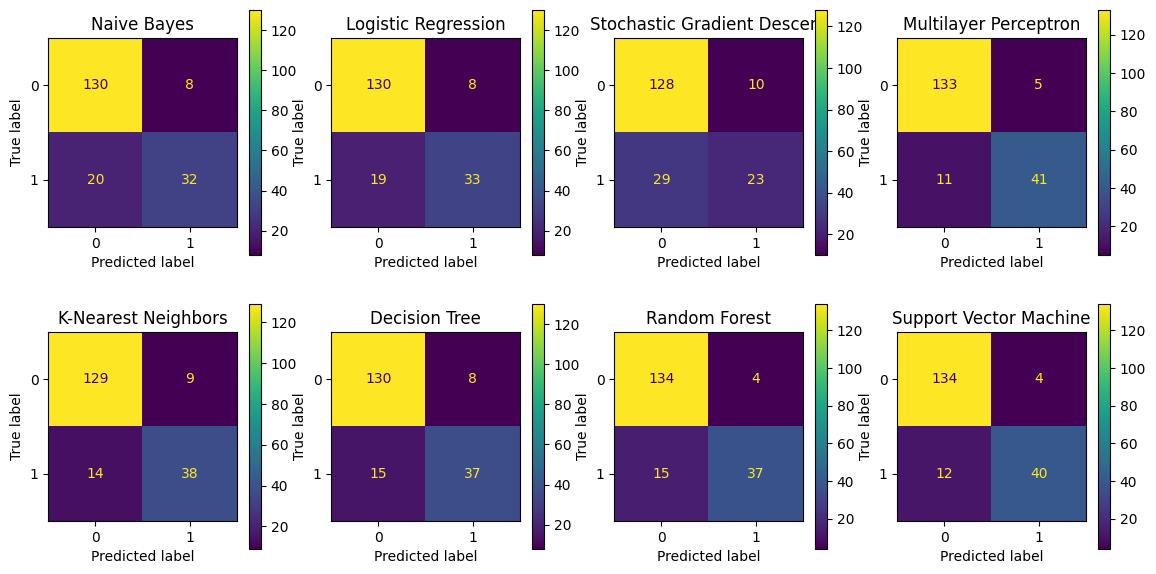

In [26]:
from sklearn.metrics import ConfusionMatrixDisplay

i = 0

plt.figure(figsize=(14, 7))

for clf, name in clsfrs:
    i += 1
    ax = plt.subplot(2, 4, i)

    ConfusionMatrixDisplay.from_estimator(
        clf,
        X_test,
        y_test,
        ax=ax
    )

    ax.set_title(name)

plt.tight_layout()
plt.show()


In [27]:
s=StandardScaler()
ds=s.fit_transform(data)
ds=pd.DataFrame(ds,columns=data.columns)
ds.head()

,cement,slag,flyash,water,superplasticizer,coarseaggregate,fineaggregate,age,csMPa,strength
0,2.588977,-0.854972,-0.905696,-0.954036,-0.702758,0.833224,-1.341873,-0.154454,2.712102,1.647339
1,2.588977,-0.854972,-0.905696,-0.954036,-0.702758,1.026458,-1.341873,-0.154454,1.623900,1.647339
2,-0.092737,0.469036,-0.905696,2.489034,-1.172447,-0.558061,-1.422013,2.015588,0.730492,1.647339
3,1.023012,0.248368,-0.905696,2.489034,-1.172447,-0.558061,-2.437123,-0.154454,0.094404,-0.607040
4,-0.092737,0.469036,-0.905696,2.489034,-1.172447,-0.558061,-1.422013,-0.154454,0.659548,1.647339


In [28]:
y_name='csMPa'
X_names=list(data.columns)[0:8]
Xs=ds[X_names].values
ys=ds[y_name].values

<Axes: xlabel='Features'>

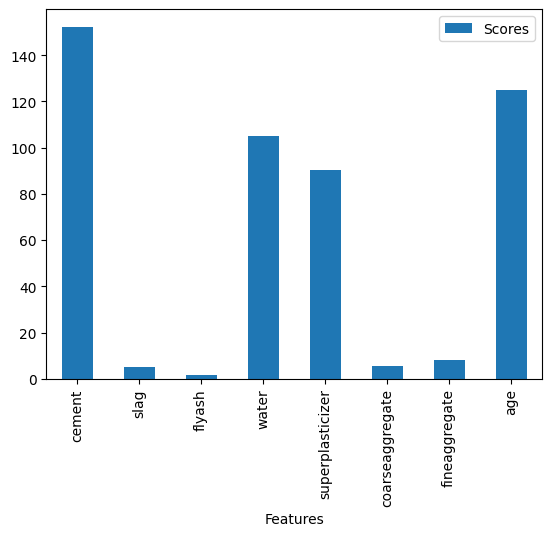

In [29]:
skb=SelectKBest(f_regression,k='all')
fit=skb.fit(X_train,y_train)
scores=pd.DataFrame({'Features':X_train.columns,'Scores':fit.scores_})
scores=scores.set_index('Features',drop=True)
scores.plot(kind='bar')

In [30]:
X_train,X_test,y_train,y_test=train_test_split(Xs,ys,test_size=0.2,random_state=101,shuffle=True)


In [31]:
from sklearn import svm

In [32]:
lin=LinearRegression()
sv=svm.SVR()
knn=KNeighborsRegressor(n_neighbors=2)
nn=MLPRegressor(hidden_layer_sizes=(3,5,3),tol=1e-6,activation='tanh',solver='lbfgs',early_stopping=True,max_iter=10000,n_iter_no_change=20)
regress=[[lin,'Linear Regression'],[sv,'Support Vector Machine'],[knn,'K-Nearest Neighbors'],[nn,'Neural Network']]
for clf,nname in regress:
  clf.fit(X_train,y_train)

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


In [33]:
for method,name in regress:
  r2=method.score(X_train,y_train)
  print (r2)

0.7728449702236814
0.9181571657683844
0.9402996007404483
0.9033953769403111


In [34]:
for method,name in regress:
  r2=method.score(X_test,y_test)
  print (r2)

0.7221018989189484
0.8686772220377899
0.6564154306450791
0.8160168573364375


/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


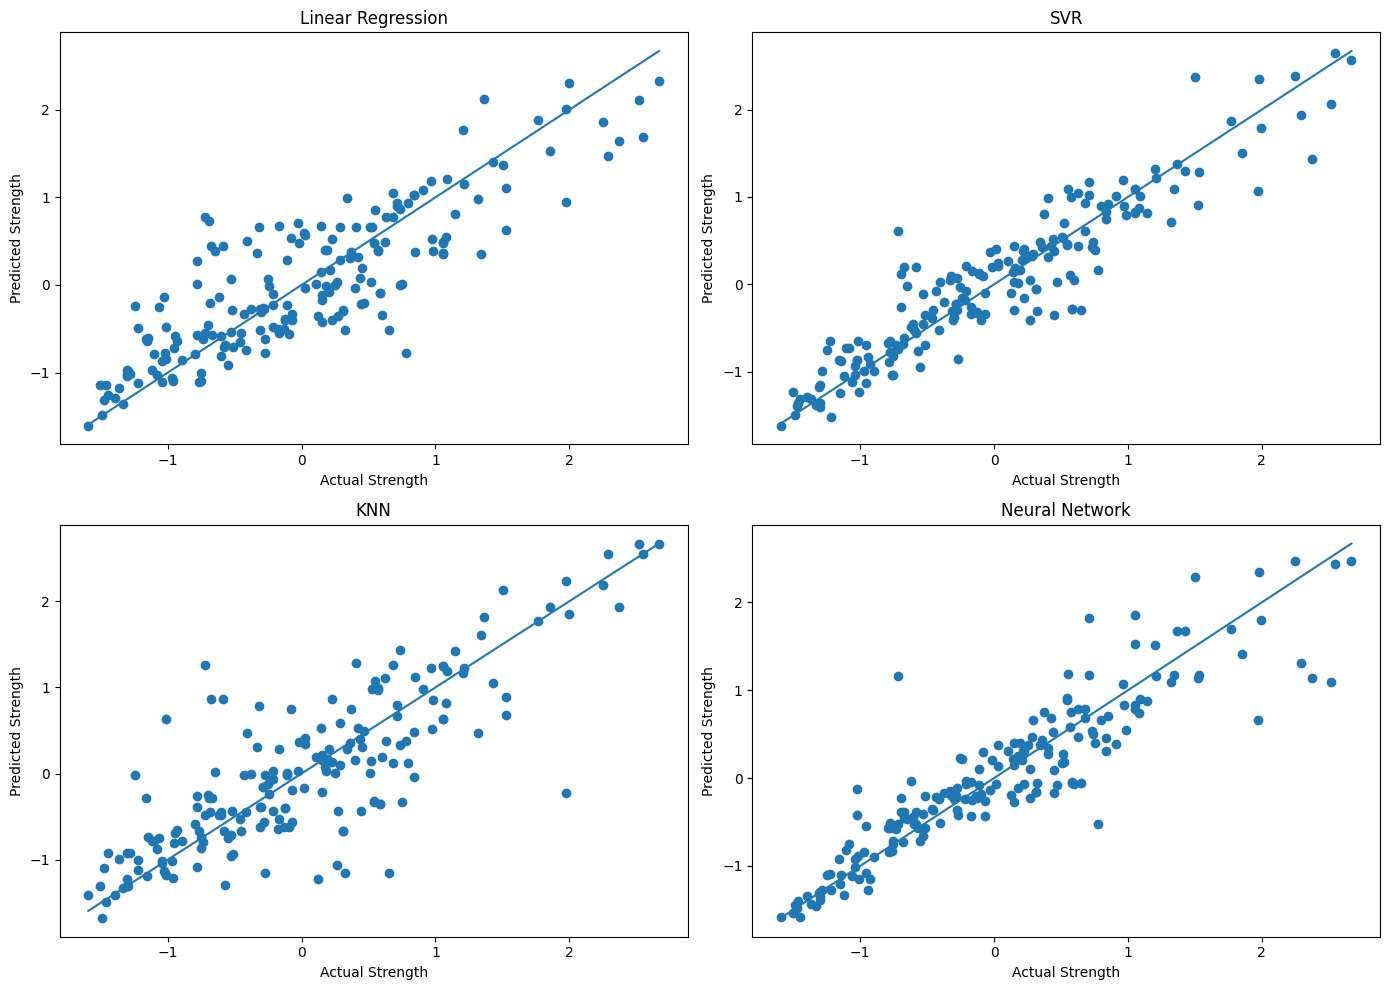

In [35]:
import matplotlib.pyplot as plt

models = [
    (lin, "Linear Regression"),
    (sv, "SVR"),
    (knn, "KNN"),
    (nn, "Neural Network")
]

plt.figure(figsize=(14, 10))

for i, (model, name) in enumerate(models, 1):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)

    plt.subplot(2, 2, i)

    plt.scatter(y_test, y_pred)

    # Ideal prediction line
    plt.plot(
        [y_test.min(), y_test.max()],
        [y_test.min(), y_test.max()]
    )

    plt.xlabel("Actual Strength")
    plt.ylabel("Predicted Strength")
    plt.title(name)

plt.tight_layout()
plt.show()

In [36]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    nn,
    X_test,
    y_test,
    n_repeats=10,
    random_state=101,
    scoring="r2"
)

importance = result.importances_mean

for feature, score in zip(X.columns, importance):
    print(feature, score)

cement 1.7141287170299038
slag 1.1299080635722787
flyash 0.4935184381590031
water 0.023666209542858162
superplasticizer 0.13607065329475482
coarseaggregate 0.2164208622406841
fineaggregate 0.2300759086905674
age 0.8963940176825705


In [37]:
def classify_grade(strength):
    if strength >= 40:
        return "M40"
    elif strength >= 35:
        return "M35"
    elif strength >= 30:
        return "M30"
    elif strength >= 25:
        return "M25"
    elif strength >= 20:
        return "M20"
    else:
        return "Below M20"

In [38]:
import joblib

joblib.dump(nn, "model.pkl")

['model.pkl']

In [39]:
joblib.dump(s, "scaler.pkl")

['scaler.pkl']

In [40]:
import joblib

joblib.dump(result.importances_mean, "feature_importance.pkl")

['feature_importance.pkl']

In [41]:
import joblib
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

# 8 input features
X = data[
    [
        "cement",
        "slag",
        "flyash",
        "water",
        "superplasticizer",
        "coarseaggregate",
        "fineaggregate",
        "age"
    ]
]

y = data["csMPa"]

# Scale ONLY the 8 input features
reg_scaler = StandardScaler()
X_scaled = reg_scaler.fit_transform(X)

# Same split as before
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=101,
    shuffle=True
)

# Train your chosen model
nn.fit(X_train, y_train)

# Save matching model + scaler
joblib.dump(nn, "model.pkl")
joblib.dump(reg_scaler, "scaler.pkl")

/usr/local/lib/python3.13/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:546: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
  self.n_iter_ = _check_optimize_result("lbfgs", opt_res, self.max_iter)


['scaler.pkl']

In [42]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    nn,
    X_test,
    y_test,
    n_repeats=10,
    random_state=101,
    scoring="r2"
)

joblib.dump(result.importances_mean, "feature_importance.pkl")

['feature_importance.pkl']

In [43]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

y_pred = nn.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

RMSE: 6.295200812884209
R²: 0.8345274716205298


In [44]:
for actual, predicted in zip(y_test[:10], y_pred[:10]):
    print("Actual:", actual, "Predicted:", predicted)

Actual: 33.7 Predicted: 30.85424982565038
Actual: 59.89 Predicted: 62.09105668310953
Actual: 42.64 Predicted: 33.03388508480787
Actual: 57.6 Predicted: 66.52005001507193
Actual: 10.38 Predicted: 9.615684462866795
Actual: 41.64 Predicted: 48.08332578183492
Actual: 30.88 Predicted: 34.736588789107415
Actual: 9.87 Predicted: 13.297348684180271
Actual: 26.23 Predicted: 31.95297891286901
Actual: 10.54 Predicted: 11.925231413108932


In [45]:
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

models = [
    (lin, "Linear Regression"),
    (sv, "Support Vector Regression"),
    (knn, "K-Nearest Neighbors"),
    (nn, "Neural Network")
]

for model, name in models:
    model.fit(X_train, y_train)
    predictions = model.predict(X_test)

    rmse = np.sqrt(mean_squared_error(y_test, predictions))
    r2 = r2_score(y_test, predictions)

    print(name)
    print("RMSE:", rmse)
    print("R²:", r2)
    print()

Linear Regression
RMSE: 8.158107552481406
R²: 0.7221018989189485

Support Vector Regression
RMSE: 8.036044181471043
R²: 0.7303556295267983

K-Nearest Neighbors
RMSE: 9.071173268860221
R²: 0.6564154306450791

Neural Network
RMSE: 6.451073730518708
R²: 0.8262316260435285



In [46]:
import joblib

sv.fit(X_train, y_train)

joblib.dump(sv, "model.pkl")
joblib.dump(reg_scaler, "scaler.pkl")

['scaler.pkl']

In [47]:
from sklearn.inspection import permutation_importance

result = permutation_importance(
    sv,
    X_test,
    y_test,
    n_repeats=10,
    random_state=101,
    scoring="r2"
)

for feature, score in zip(X.columns, result.importances_mean):
    print(feature, score)

joblib.dump(result.importances_mean, "feature_importance.pkl")

cement 0.24437966754147808
slag 0.06542520435263227
flyash 0.02717337236888854
water 0.10488748322549561
superplasticizer 0.09344509215252458
coarseaggregate 0.02319268223390525
fineaggregate 0.045616159667780154
age 0.5513714656228933


['feature_importance.pkl']